In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import jax
jax.config.update("jax_enable_x64", True)

## Monolayer

#### How to create basic crystal

In [ ]:
"""
How to create a basic 2D monolayer crystal

This example demonstrates how to construct a simple rectangular lattice:
  1. Define primitive unit cell vectors.
  2. Build a finite supercell by tiling the primitive cell.
  3. Generate particle positions at each lattice site in the supercell.

The aspect ratio λ = a₁/a₂ controls the lattice geometry.
"""
import numpy as np
import jax.numpy as jnp
from ezwald import geometry as geo

# 1. Define primitive cell for rectangular lattice (aspect ratio lambda < 1)
lam = 0.95         # aspect ratio (a₁/a₂ < 1)
a2 = 1.0           # lattice constant along y-axis
a1 = lam * a2      # lattice constant along x-axis

# Primitive cell vectors (rows are lattice vectors)
axes_primitive = np.diag([a1, a2])

# 2. Build supercell by tiling primitive cell
nx = 3              # repeats along x
ny = 2              # repeats along y
axes = np.diag([nx, ny]) @ axes_primitive

# 3. Generate lattice positions: one particle per lattice site
latvec = axes / np.array((nx, ny))[:, None]
pos = geo.gen_lattice(latvec, (nx, ny), kspace=False)

print("Primitive cell axes:\n", axes_primitive)
print("Supercell axes:\n", axes)
print("Number of particles:", len(pos))

#### How to graph

In [ ]:
"""
How to visualize the 2D monolayer lattice

Steps:
  1. Draw the simulation cell boundary.
  2. Plot particle positions as points.
"""
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

# Draw the supercell in red
draw_cell(ax, axes, color="r")

# Plot particle positions as dots
ax.plot(*pos.T, ls="", marker=".", color="k")

ax.set_xlabel("x (Borh)")
ax.set_ylabel("y (Borh)")
ax.set_title("2D monolayer supercell")

#### How to get energy of a crystal

In [ ]:
"""
How to compute Coulomb energy of a crystal with ezwald

Steps:
  1. Initialize Ewald object with supercell geometry.
  2. Assign charges to each particle.
  3. Compute total and per-particle Coulomb energy.
"""
from ezwald import ewald

# 1. Initialize Ewald summation for this supercell
ew, rvecs, kvecs = ewald.make_ewald(axes)

# 2. Assign charges: here we take all particles to have charge -1
charge = -jnp.ones(len(pos))

# 3. Compute total Coulomb energy using Ewald summation
total_energy = ew.sum(pos, charge, rvecs, kvecs)
energy_per_particle = total_energy / len(pos)

print("N =", len(pos))
print("E_total =", float(total_energy))
print("E/N =", float(energy_per_particle))

#### How to know its correct

In [ ]:
"""
How to compare with reference results (from Bonsall-Maradudin)
The paper quotes energies in the form

    E_l(λ) = -3.898597 * e^2 / (a_c)^(1/2)    for λ = 0.95,  Eq. (2.20)
This formula will be different for each crystal, reference paper for different formulas.

where:
  - E_l(λ) is the energy per *lattice site* (per particle),
  - e is the electron charge (we set e = 1),
  - a_c is the area (2D “volume”) of the primitive cell.

To compare our ezwald result to the paper:

  1. Compute the primitive cell area a_c from the 2x2 primitive axes matrix.
  2. Compute the total Coulomb energy E_total from ezwald.
  3. Convert to energy per particle E_num = E_total / N.
  4. Form the *dimensionless* energy

         E_dimless = E_num * (a_c)**0.5 / e**2

     (with e = 1, this is just E_num * sqrt(a_c)).
  5. Compare new E_dimless to the tabulated coefficient (-3.898597 for λ = 0.95).
  
Reference:
  "Some static and dynamical properties of a two-dimensional Wigner crystal"
  L. Bonsall and A. A. Maradudin, Phys. Rev. B 15, 1959 (1977).
"""

#### How to generate different crystals

In [ ]:
"""
How to generate different 2D Bravais lattices

You can change the primitive cell matrix `axes_primitive` to generate:
  - Oblique
  - Primitive rectangular
  - Centered rectangular
  - Square
  - Hexagonal (triangular)

The Bonsall-Maradudin paper lists lattice vectors for each case.
"""
import numpy as np
from ezwald import geometry as geo

# Example: hexagonal (triangular) lattice
# Each row is a primitive lattice vector
axes_primitive = np.array([
    [1.0, 0.0],
    [-0.5, np.sqrt(3) / 2]
])

# Build supercell
axes = np.diag([nx, ny]) @ axes_primitive

# Generate one particle per lattice site
latvec = axes / np.array((nx, ny))[:, None]
pos = geo.gen_lattice(latvec, (nx, ny), kspace=False)

print("Primitive cell axes:\n", axes_primitive)
print("Supercell axes:\n", axes)
print("Tiling:", (nx, ny))
print("Number of particles:", len(pos))

#### How to tile a crystal

In [ ]:
"""
How to tile a crystal from a smaller reference cell

This demonstrates building larger systems by repeating a base unit.

Steps:
  1. Define reference cell with particle basis.
  2. Use geo.tile() to replicate over a mesh.
"""
from ezwald import geometry as geo

# 1. Define 2×2 reference cell
alat = 1.0
reg_cell = 2 * np.array([[alat, 0.0],
                         [0.0,  alat]])

# Two displacement vectors for the basis (here in lattice coordinates)
disp = np.array([[0.0, 0.0],
                 [0.5, 0.5]]) / 2.0

# Reference basis positions inside the cell (lattice coordinates)
x0 = np.array([[0.0, 0.0],
               [0.5, 0.0],
               [0.0, 0.5],
               [0.5, 0.5]])

# Combine basis + displacements and map to Cartesian
x = np.concatenate([_disp + x0 for _disp in disp])
reg_pos = x @ reg_cell

# 2. Tiling factors in x and y
nx, ny = 2, 2
cell = np.diag((nx, ny)) @ reg_cell
pos = geo.tile(reg_pos, (nx, ny), reg_cell)

print("Reference cell:\n", reg_cell)
print("Tiled cell:\n", cell)
print("Number of particles:", len(pos))

In [ ]:
"""
Optional: visualize the tiled crystal
"""
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

draw_cell(ax, axes, color='r')
ax.plot(*pos.T, ls='', marker='x')

ax.set_title("Tiled crystal")
plt.show()

#### How to use optimization to relax the crystal

In [ ]:
import jax.numpy as jnp
import numpy as np
from ezwald import ewald, lattice, geometry as geo

#Refer to "How to create basic crystal" guide
lam = 0.95         
a2 = 1.0          
a1 = lam * a2   
axes_primitive = np.diag([a1, a2])
nx, ny = 2, 2          
axes = np.diag([nx, ny]) @ axes_primitive
latvec = axes / np.array((nx, ny))[:, None]
pos = geo.gen_lattice(latvec, (nx, ny), kspace=False)

# optimization step function
# (Don't modify unless changing optimizer logic)
@jax.jit
def step(params, opt_state):
    """Single gradient descent step: compute loss → gradients → update parameters"""
    loss_value, grads = grad_fn(params) # grad_fn defined in position/cell sections below
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_value

# geomtry optimization setup
import optax

# Learning rate schedule (adjust for convergence speed vs stability)
schedule = optax.exponential_decay(
    init_value=0.2,        # initial learning rate (decrease if optimization diverges)
    transition_steps=1000, # steps until lr decays by decay_rate
    decay_rate=0.5         # multiply lr by this every transition_steps
)
# Optimizer chain (adjust for different optimization behavior)
optimizer = optax.chain(
    optax.clip(1.0),       # gradient clipping (increase if gradients are small, decrease if unstable)
    optax.adam(schedule),  # Adam optimizer with learning rate schedule
                           # alternatives: optax.sgd(schedule), optax.rmsprop(schedule)
)

# Build Ewald object and compute lattice vectors for real/reciprocal space
ew, rvecs, kvecs = ewald.make_ewald(axes)
rc, kc = lattice.compute_cutoffs(axes, 15.0)
latidx = lattice.lattice_indices(axes, rc, kc)
rvecs, kvecs = lattice.transform_lattice(latidx, axes)

charge = -1*jnp.ones(len(pos))
ew.sum(pos, charge, rvecs, kvecs)

nstep = 1000 # number of optimization steps (increase for possibly better convergence)

# Follow guide for either:
#   1. "Optimize Positions" → freeze cell, relax particle positions only
#   2. "Optimize Positions and Cell" → relax both positions and lattice parameters

##### Optimize Positions

In [ ]:
# OPTIMIZATION: Positions only
# This section shows how to relax particle positions while
# keeping the simulation cell (axes) fixed.
#
# The loss function changes if optimizing positions vs positions and cell.
# For position-only optimization:
#   - params = positions (a single array)
#   - The cell axes remain constant throughout
#
# For cell+position optimization (see the other guide):
#   - params = {"axes": ..., "pos": ...} (a dictionary)
#   - Both positions and cell parameters are optimized

@jax.jit
def loss(params):
    """
    Compute the total Coulomb energy for a given set of particle positions.
    
    Parameters:
        params: The positions array (shape: [N, 2] for N particles in 2D)
                For position-only optimization, params is just the positions.
                For cell+position optimization, params would be a dict with
                both "axes" and "pos" keys.
    
    Returns:
        Total electrostatic energy computed via Ewald summation.
    """
    pos = params
    return ew.sum(pos, charge, rvecs, kvecs)

# Compute the energy before optimization starts.
# This gives us a baseline to compare against after optimization.
initial_energy = loss(pos)
print(f"Initial energy: {initial_energy:.6f}")

# Create the gradient function
# jax.value_and_grad() returns a function that computes BOTH:
#   1. The loss value (the energy)
#   2. The gradient of the loss with respect to params (∂E/∂pos)
#
# Why use value_and_grad instead of just grad?
#   - We need the gradient to update parameters (gradient descent)
#   - We also want to monitor the loss value during optimization
#   - Computing both together is more efficient than two separate calls
#
# The @jax.jit decorator compiles this function for speed.
grad_fn = jax.jit(jax.value_and_grad(loss))

# Test the gradient function on initial positions
# This returns: (loss_value, gradient_array)
test_loss, test_grad = grad_fn(pos)
print(f"Test gradient computation successful. Loss: {test_loss:.6f}")
print(f"Gradient shape: {test_grad.shape}")  # Should match pos.shape

# Initialize the optimizer state
opt_state = optimizer.init(pos)

# Create a copy of the initial positions to serve as our starting point.
# We'll update this array during optimization.
params = pos.copy()

# Run the optimization loop
# ============================================================
# Each iteration:
#   1. Computes the energy and gradient at current params
#   2. Uses the optimizer to compute parameter updates
#   3. Applies updates to get new params
#   4. Stores the new optimizer state
#
# The number of steps controls how long we optimize:
#   - Too few: may not reach the minimum energy
#   - Too many: wastes computation time if already converged
nstep = 1000  # Number of gradient descent iterations

for i in range(nstep):
    # step() is defined earlier in the notebook and does
    params, opt_state, loss_value = step(params, opt_state)

# Compute final energy after optimization
final_energy = loss(params)
print(f"\nOptimization complete!")
print(f"Initial energy: {initial_energy:.6f}")
print(f"Final energy:   {final_energy:.6f}")
print(f"Energy change:  {final_energy - initial_energy:.6f}")

# Visualize initial vs optimized positions
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, axes, color='k')

ax.plot(*pos.T, ls='', marker='x') #Unoptimized
ax.plot(*params.T, ls='', marker='+') #Optimized

# Plot initial (unoptimized) positions as 'x' markers
ax.plot(*pos.T, ls='', marker='x', color='blue', label='Unoptimized')

# Plot final (optimized) positions as '+' markers
# After optimization, particles should have moved to lower-energy positions
ax.plot(*params.T, ls='', marker='+', color='red', label='Optimized')

# Add labels and legend
ax.set_xlabel('x (Bohr)', fontsize=12)
ax.set_ylabel('y (Bohr)', fontsize=12)
ax.set_title('Position optimization: initial → relaxed', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##### Optimize Positions and Cell

In [ ]:
# OPTIMIZATION: Positions AND Cell
# This section shows how to simultaneously relax BOTH:
#   1. Particle positions (pos)
#   2. Simulation cell parameters (axes)
#
# Key difference from position-only optimization:
#   - params is now a DICTIONARY with 'axes' and 'pos' keys
#   - The lattice vectors (rvecs, kvecs) must be recomputed
#     each step because the cell is changing
#
# This is more expensive but allows the crystal structure
# itself to relax (e.g., changing aspect ratio, area, etc.)

@jax.jit
def loss(params):
    """
    Compute the total Coulomb energy for BOTH positions and cell parameters.
    
    Parameters:
        params: A dictionary with keys:
                - 'axes': The 2x2 lattice matrix (cell shape/size)
                - 'pos': The particle positions array [N, 2]
    
    Returns:
        Total electrostatic energy computed via Ewald summation.
    """
    axes = params['axes']
    rvecs, kvecs = lattice.transform_lattice(latidx, axes)
    pos = params['pos']
    return ew.sum(pos, charge, rvecs, kvecs)

# Create the gradient function
# jax.value_and_grad() will now compute gradients with respect to
# BOTH params['axes'] and params['pos'] simultaneously.
#
# The returned gradient will be a dictionary with the same structure:
#   grads = {'axes': ∂E/∂axes, 'pos': ∂E/∂pos}
#
# This allows the optimizer to update both the cell and positions
# using their respective gradients.
grad_fn = jax.jit(jax.value_and_grad(loss))

# Initialize the parameter dictionary
params = {
    'axes': axes, # Initial cell
    'pos': pos,   # Initial positions
}

# Test the loss function and gradient on initial configuration
initial_energy = loss(params)
print(f"Initial energy: {initial_energy:.6f}")

test_loss, test_grads = grad_fn(params)
print(f"Test gradient computation successful. Loss: {test_loss:.6f}")
print(f"Gradient keys: {test_grads.keys()}")
print(f"  ∂E/∂axes shape: {test_grads['axes'].shape}")
print(f"  ∂E/∂pos shape:  {test_grads['pos'].shape}")

# Initialize the optimizer state
opt_state = optimizer.init(params)

nstep = 1000  # Number of gradient descent iterations

# Run the optimization loop
for i in range(nstep):
    params, opt_state, loss_value = step(params, opt_state)

# Extract optimized results
axes1 = params['axes']
pos1 = params['pos']

# Compute final energy
final_energy = loss(params)
print(f"\nOptimization complete!")
print(f"Initial energy: {initial_energy:.6f}")
print(f"Final energy:   {final_energy:.6f}")
print(f"Energy change:  {final_energy - initial_energy:.6f}")

# Print how the cell changed
print(f"\nInitial cell axes:\n{axes}")
print(f"Final cell axes:\n{axes1}")
print(f"Cell area change: {np.linalg.det(axes):.6f} → {np.linalg.det(axes1):.6f}")

# Visualize initial vs optimized configuration
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

draw_cell(ax, axes, color='k')
ax.plot(*pos.T, ls='', marker='x', c='k') #Unoptimized

draw_cell(ax, axes1, color='r')
ax.plot(*pos1.T, ls='', marker='+', c='r' )#Optimized

# -------- Draw INITIAL (unoptimized) configuration --------
# Draw the initial cell boundary (blue)
draw_cell(ax, axes, color='blue')

# Plot initial particle positions (blue 'x')
ax.plot(*pos.T, ls='', marker='x', color='blue', label='Unoptimized (cell + positions)')

# -------- Draw OPTIMIZED configuration --------
# Draw the optimized cell boundary (red)
# Note: the cell shape/size may have changed during optimization!
draw_cell(ax, axes1, color='r')

# Plot optimized particle positions (red '+')
ax.plot(*pos1.T, ls='', marker='+', color='red', label='Optimized (cell + positions)')

# Add labels and styling
ax.set_xlabel('x (Bohr)', fontsize=12)
ax.set_ylabel('y (Bohr)', fontsize=12)
ax.set_title('Cell + Position optimization: initial → relaxed', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



#### How to show defects (Odd number of charges, different charge, and randomize position of charges)

In [ ]:
#To show defects: have an odd number of charges, change charge to be positive, and randomize positions of charges

#Define number of charges:
ntotalelectrons = 9 #Can make odd to see what interesting crystals form

#Define primitive cell:
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
]) #rectangular

#Randomizes position of charges:
fraction_cord = np.random.rand(ntotalelectrons, 2) #num points, dimensions, goes between 0 and 1
pos = fraction_cord@cell

#Create cell:
lam = 0.95         # aspect ratio a1/a2
a2 = 1.0           # lattice constant along y
a1 = lam * a2      # lattice constant along x
axes_primitive = np.diag([a1, a2])
nx = 2             # number of repeats in x and y
axes = nx * axes_primitive
ew, rvecs, kvecs = ewald.make_ewald(axes)

#Adjust charge here:
charge = jnp.ones(len(pos)) #redefine charge to positive to allow for holes

#Compute energy:
total_energy = ew.sum(pos, charge, rvecs, kvecs)
energy_per_particle = total_energy / len(pos)

#Plots:
import matplotlib.pyplot as plt
from vis import draw_cell
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, axes, color="r")
ax.plot(*pos.T, ls="", marker=".", color="k")
ax.set_xlabel("x (Borh)")
ax.set_ylabel("y (Borh)")
ax.set_title("2D monolayer supercell")

#### How to go from monolayer to bilayer

Unit cell axes:
 [[2.         0.        ]
 [0.         3.46410162]]
Number of particles: 8


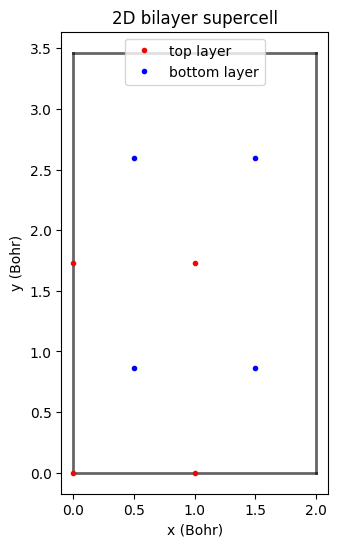

E_total = -11.307782237232841
E/N = -1.4134727796541051


In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from ezwald import bilayer_sum
from vis import draw_cell

# ----------------------------
# 1) Build a bilayer crystal
# ----------------------------
alat = 1.0
cell = 2 * np.array([
    [alat, 0.0],
    [0.0, np.sqrt(3) * alat]
])

# Use the same monolayer basis, then duplicate it into two layers
x0 = np.array([
    [0.0, 0.0],
    [0.5, 0.0],
    
    [0.0, 0.5],
    [0.5, 0.5],
])

# Layer offsets in fractional coordinates of the cell
disp = np.array([
    [0.0, 0.0],      # top layer
    [0.25, 0.25],    # bottom layer
])

pos_top = (x0 + disp[0]) @ cell
pos_bot = (x0 + disp[1]) @ cell
pos = np.vstack([pos_top, pos_bot])

print("Unit cell axes:\n", cell)
print("Number of particles:", len(pos))

# ----------------------------
# 2) Plot the bilayer
# ----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, aspect=1)

draw_cell(ax, cell, color="k")
ax.plot(*pos_top.T, ls="", marker=".", color="r", label="top layer")
ax.plot(*pos_bot.T, ls="", marker=".", color="b", label="bottom layer")

ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("2D bilayer supercell")
ax.legend()
plt.show()

# ----------------------------
# 3) Bilayer Coulomb energy
# ----------------------------
d = 1.3
bew = bilayer_sum.EwaldSumSlab(cell, d)

charge = -jnp.ones(len(pos))
total_energy = bew.energy(charge, pos)
energy_per_particle = total_energy / len(pos)

print("E_total =", float(total_energy))
print("E/N =", float(energy_per_particle))

## Bilayer

#### How to create basic crystal

In [2]:
"""
How to create a basic 2D bilayer crystal

In this section we:
  1. Define a primitive 2D unit cell for the bilayer.
  2. Specify the relative layer displacements within the unit cell.
  3. Generate particle positions for both layers.
"""
import numpy as np

# 1. Primitive cell: rectangular supercell for a 2D bilayer
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
])

# 2. Layer displacements: offset each layer within the unit cell
disp = np.array([[0,0],[0.5, 0.5]]) /2

# 3. Basis positions: four sites per layer, then combine both layers
x0 = np.array([[0,0],[0.5,0],[0,0.5],[0.5,0.5]]) #first layer centered at 0,0, define x0 in monolayer
x = np.concatenate([_disp + x0 for _disp in disp]) #2 layers together, move for loop out
pos = x@cell

# what is xo and x and how does disp connect those, take x0(monolayer) and use some shift (disp) to add layer

print("Unit cell axes:\n", cell)
print("Number of particles:", len(pos))
print("Particle positions:\n", pos)

Unit cell axes:
 [[2.         0.        ]
 [0.         3.46410162]]
Number of particles: 8
Particle positions:
 [[0.         0.        ]
 [1.         0.        ]
 [0.         1.73205081]
 [1.         1.73205081]
 [0.5        0.8660254 ]
 [1.5        0.8660254 ]
 [0.5        2.59807621]
 [1.5        2.59807621]]


#### How to graph

Text(0.5, 1.0, '2D bilayer supercell')

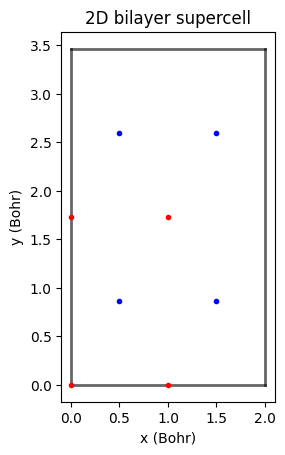

In [4]:
"""
How to plot a crystal configuration

We:
  1. Draw the simulation cell.
  2. Plot particle positions inside the cell.
"""
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

# Draw the supercell in black
draw_cell(ax, cell, color="k")

# Plot particle positions as dots
pos_t, pos_b = np.array_split(pos,2) #splits layers for visualization
ax.plot(*pos_t.T, ls="", marker=".", color="r") #red
ax.plot(*pos_b.T, ls="", marker=".", color="b") #blue

ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("2D bilayer supercell")

#### How to get energy of a crystal

In [5]:
"""
How to compute Coulomb energy of a bilayer crystal with ezwald

We:
  1. Build a slab Ewald object for the bilayer supercell.
  2. Assign charges to each particle in both layers.
  3. Compute total and per-particle Coulomb energy, and an optional rescaled energy.
"""
import numpy as np
import jax.numpy as jnp
from ezwald import bilayer_sum

# 1. Build Ewald slab object for the bilayer
#    Here `cell` is the in-plane lattice matrix and `d` is the interlayer spacing.
d = 1.5
bew = bilayer_sum.EwaldSumSlab(cell, d)

# 2. Assign charges: here we take all particles to have charge -1 (in units of e)
charge = -jnp.ones(len(pos))

# 3. Compute total Coulomb energy using the bilayer Ewald summation
total_energy = bew.energy(charge, pos)
energy_per_particle = total_energy / len(pos)

print("N =", len(pos))
print("E_total =", float(total_energy))
print("E/N =", float(energy_per_particle))

N = 8
E_total = -11.27061201889377
E/N = -1.4088265023617212


#### How to know its correct

In [ ]:
"""
How to compare with reference results (from Goldoni–Peeters)

The paper quotes bilayer energies in the dimensionless form

    E / (e^2 * sqrt(n))                                      (their Eqs. (16)–(17))

where:
  - E is the total energy per particle (per electron),
  - e is the electron charge (we set e = 1),
  - n is the total 2D particle density (both layers combined).

To compare our ezwald bilayer result to the paper:

  1. Compute the total areal density
         n = N / A
     where N is the total number of particles in both layers and
     A is the in-plane area of the simulation cell, A = det(cell).

  2. Compute the total Coulomb energy E_total from the bilayer Ewald sum.
     The ezwald bilayer routine gives E_total for the N-particle system.

  3. Convert to energy per particle
         E_num = E_total / N.

  4. Form the *dimensionless* energy used in the paper

         E_dimless = E_num / (e^2 * sqrt(n))

     (with e = 1, this is just E_num / sqrt(n)).

  5. For a given value of the dimensionless parameter
         η = d * sqrt(n / 2)
     (their definition), evaluate the analytic expression for
     E / (e^2 * sqrt(n)) from Eqs. (16)–(17) and compare
     to our numerical E_dimless as a function of η.

Reference:
  "Stability, dynamical properties, and melting of a classical bilayer
   Wigner crystal", G. Goldoni and F. M. Peeters,
   Phys. Rev. B 53, 4591 (1996).
"""
import numpy as np
import jax.numpy as jnp

# 1. Total areal density n from the bilayer simulation cell
N = len(pos)                          # total number of particles (both layers)
A = abs(np.linalg.det(cell))          # in-plane cell area
n = N / A                             # total 2D density

# 2. Total Coulomb energy from bilayer Ewald sum (see previous section)
total_energy = bew.energy(charge, pos)

# 3. Energy per particle
energy_per_particle = total_energy / N

# 4. Dimensionless energy E / (e^2 * sqrt(n)), with e = 1. The energy rescaling is based on an areal density n.
E_dimless = energy_per_particle / jnp.sqrt(n)

# 5. Dimensionless interlayer parameter η used in the paper
eta = d * jnp.sqrt(n / 2.0)

print("N =", int(N))
print("Area A =", float(A))
print("Density n =", float(n))
print("η =", float(eta))
print("E_per_particle =", float(energy_per_particle))
print("E / (e^2 * sqrt(n)) =", float(E_dimless))

#### How to generate different crystals

In [ ]:
"""
How to generate different bilayer crystal phases

You can change the primitive cell matrix `cell` and the layer offset `disp`
to generate the five bilayer phases:
  - Phase I: one-component hexagonal (triangular)
  - Phase II: staggered rectangular
  - Phase III: staggered square
  - Phase IV: staggered rhombic
  - Phase V: staggered hexagonal

The Goldoni-Peeters paper lists the primitive vectors a1, a2
and interlayer displacement c for each case.
"""
import numpy as np

# Example: Phase III (staggered square)
a = 1.0
cell = a * np.array([
    [1.0, 0.0],
    [0.0, 1.0],
])

# Relative offset between the two layers
disp = 0.5 * (cell[0] + cell[1])

# One particle basis for each layer
x0 = np.array([[0.0, 0.0]])
x = np.concatenate([x0, x0 + disp])
pos = x @ cell

#code cell based on table

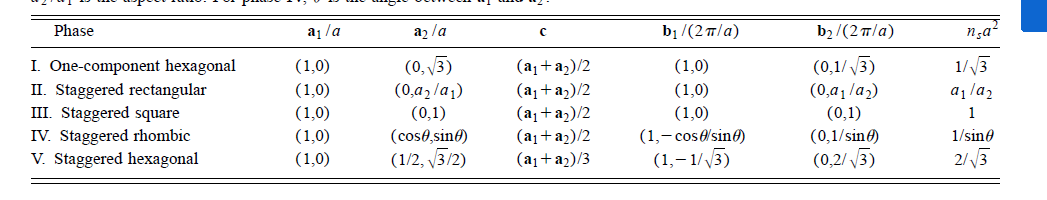

#### How to tile a crystal

In [ ]:
"""
How to tile a bilayer crystal from a smaller reference cell

We:
  1. Define a reference bilayer cell and positions inside it.
  2. Tile the configuration to build a larger bilayer supercell.
"""
import numpy as np
from ezwald import geometry as geo

def tile(pos, mesht, cell):
    """Tile positions `pos` over an integer mesh using lattice vectors `cell`."""
    ndim = len(cell)
    rvecs = geo.gen_lattice(cell, mesht, kspace=False)
    all_pos = rvecs[:, None] + pos[None, :]
    pos1 = all_pos.reshape(-1, ndim)
    return pos1

#Refer to "How to create basic crystal" guide
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
])
disp = np.array([[0,0],[0.5, 0.5]]) /2
x0 = np.array([[0,0],[0.5,0],[0,0.5],[0.5,0.5]])
x = np.concatenate([_disp + x0 for _disp in disp])
pos = x@cell

# For visualization: split positions into top/bottom layers
pos_t, pos_b = np.array_split(pos,2) #splits layers for visualization

# 2. Tiling factors in x and y, tile top and bottom sep
nx, ny = 3, 2
pos_top_tiled = tile(pos_t, (nx, ny), cell)
pos_bottom_tiled = tile(pos_b, (nx, ny), cell)
pos_tiled = np.concatenate([pos_top_tiled, pos_bottom_tiled], axis=0)

print("Reference cell:\n", cell)
print("Number of particles (tiled):", len(pos_tiled))

In [ ]:
"""
Optional: visualize the tiled crystal
"""
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

# Draw the supercell in black
draw_cell(ax, cell, color="k")

# Plot particle positions as dots
ax.plot(*pos_top_tiled.T, ls="", marker=".", color="r") #red
ax.plot(*pos_bottom_tiled.T, ls="", marker=".", color="b") #blue

ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("Tiled crystal")

#### How to use optimization to relax the crystal

In [6]:
import jax.numpy as jnp
import numpy as np
from ezwald import bilayer_sum

#Refer to "How to create basic crystal" guide
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
])
disp = np.array([[0,0],[0.5, 0.5]]) /2
x0 = np.array([[0,0],[0.5,0],[0,0.5],[0.5,0.5]])
x = np.concatenate([_disp + x0 for _disp in disp])
pos = x@cell

@jax.jit
def step(params, current_state): #same as monolayer
    loss_value, grads = grad_fn(params) #gradiant
    updates, current_state = optimizer.update(grads, current_state, params) 
    params = optax.apply_updates(params, updates)
    return params, current_state, loss_value

# geomtry optimization
import optax
schedule = optax.exponential_decay(init_value=0.2, transition_steps=1000, decay_rate=0.5) #mess with this, add picture of learning rate when decayed
optimizer = optax.chain(
    optax.clip(1.0),
    optax.adam(schedule),
)

charge = -1*jnp.ones(len(pos))
d= 1.3 #change this distance between layers
bew = bilayer_sum.EwaldSumSlab(cell, d)
e = bew.energy(charge, pos)/len(pos)
nstep = 1000

# Follow guide for either positions or positions and cell optimization

##### Optimize Positions

In [ ]:
#The loss functions changes if optimizing positions vs positions and cell 
@jax.jit
def loss(params):
    pos = params
    charge = -1*jnp.ones(len(pos))
    return bew.energy(charge, pos)/len(pos)

# Evaluate loss and its gradient at the initial configuration
loss(pos)
grad_fn = jax.jit(jax.value_and_grad(loss))
grad_fn(pos)

# Run gradient-based optimization on the positions
opt_state = optimizer.init(pos)
params = pos.copy()
for i in range(nstep): #actual opt, how does it do it
    params, opt_state, loss_value = step(params, opt_state)

# Visualize initial bilayer configuration
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 2, 1, aspect=1)
draw_cell(ax, cell, color='k')
pos_t, pos_b = np.array_split(pos,2) 
ax.plot(*pos_b.T, ls='', marker='.', color='b', label="top")
ax.plot(*pos_t.T, ls='', marker='.', color='r', label="bottom")
ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("Unoptimized")
ax.legend()

# Visualize both optimized layers separately inside one primitive cell
np.linalg.inv(cell) 
fracs = params @ np.linalg.inv(cell) # Cartesian -> fractional coordinates
fracs %1                             # Wrap into [0, 1)
pos1 = (fracs%1)@cell                # Back to Cartesian in reference cell

pos_t, pos_b = np.array_split(pos1,2) 

# fig = plt.figure()
ax = fig.add_subplot(1, 2, 2, aspect=1)
draw_cell(ax, cell, color='k')
ax.plot(*pos_b.T, ls='', marker='.', color='b')
ax.plot(*pos_t.T, ls='', marker='.', color='r')
ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("Optimized")

##### Optimize Positions and Cell

Text(0.5, 1.0, 'Optimized')

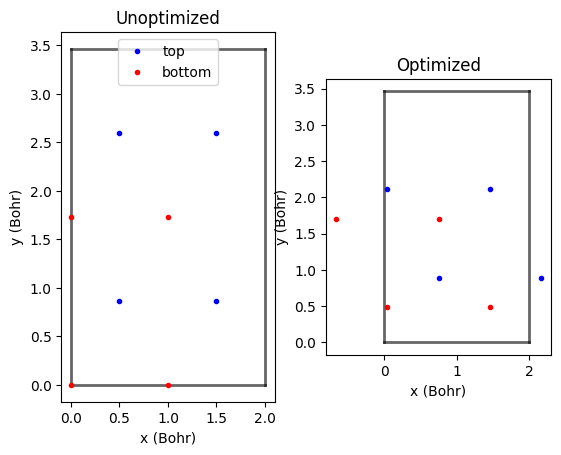

In [15]:
from ezwald import geometry as geo

#The loss functions changes if optimizing positions vs positions and cell 
@jax.jit
def loss(params):
    a = params["a"]
    theta = params["theta"]
    cell = make_cell(areac, a, theta)
    pos = params["pos"]
    recvec = geo.calc_recvec(cell)
    gpoints = gidx @ recvec
    bew =  bilayer_sum.EwaldSumSlab(cell, d, disp_fn_mode='gen', gpoints = gpoints)
    return bew.energy(charge, pos)/len(pos)

params = {
    'a':  cell[0,0],
    'theta': np.pi/2,
    'pos': pos,
}


def make_cell(area, a, theta):
    b = area/(a*jnp.sin(theta))
    cell = jnp.array([
        [a, 0],
        [b*jnp.cos(theta), b*jnp.sin(theta)],
    ])
    return cell
areac = abs(np.linalg.det(cell))
make_cell(areac, cell[0,0], np.pi/3) #opt cell


bew = bilayer_sum.EwaldSumSlab(cell, d)
recvec = geo.calc_recvec(cell)
gcands = bew.gpoints @ np.linalg.inv(recvec)
gidx = np.array(gcands.round(), dtype=int) #preacllocated
# np.allclose(gidx, gcands)

# Evaluate loss and its gradient at the initial configuration
loss(params)
grad_fn = jax.jit(jax.value_and_grad(loss))
grad_fn(params)

# Run gradient-based optimization on the positions
opt_state = optimizer.init(params)

for i in range(nstep): #actual opt, how does it do it
    params, opt_state, loss_value = step(params, opt_state)

# Visualize initial bilayer configuration
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 2, 1, aspect=1)
draw_cell(ax, cell, color='k')
pos_t, pos_b = np.array_split(pos,2) 
ax.plot(*pos_b.T, ls='', marker='.', color='b', label="top")
ax.plot(*pos_t.T, ls='', marker='.', color='r', label="bottom")
ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("Unoptimized")
ax.legend()

# Extract optimized values from params
cell1 = make_cell(areac, params['a'], params['theta'])
pos1 = params['pos']

# Visualize both optimized layers separately inside one primitive cell
fracs = pos1 @ np.linalg.inv(cell1)  # takes to fractional
fracs = fracs % 1

pos2 = (fracs % 1) @ cell1
pos_t, pos_b = np.array_split(pos2, 2)  # splits layers

# fig = plt.figure()
ax = fig.add_subplot(1, 2, 2, aspect=1)
draw_cell(ax, cell, color='k')
ax.plot(*pos_b.T, ls='', marker='.', color='b')
ax.plot(*pos_t.T, ls='', marker='.', color='r')
ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("Optimized")

#### How to show defects

energy per particle = -0.14030440328208918


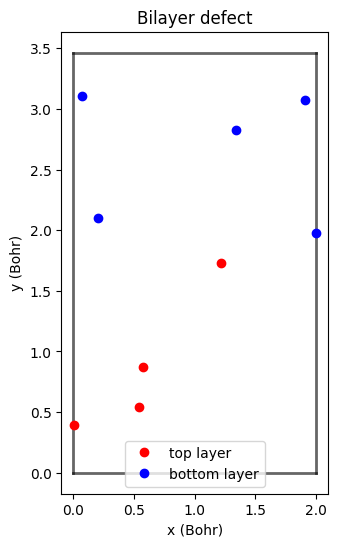

In [9]:
import numpy as np
import jax.numpy as jnp
from ezwald import ewald, lattice, geometry as geo
from ezwald import bilayer_sum
import matplotlib.pyplot as plt
from vis import draw_cell

# Use an odd total number 
ntotalelectrons = 9

# Split into two layers explicitly
ntop = ntotalelectrons // 2      # 4
nbot = ntotalelectrons - ntop    # 5

alat = 1.0
cell = 2 * np.array([
    [alat, 0.0],
    [0.0, np.sqrt(3) * alat]
])  # rectangular simulation cell

# Randomize positions independently in each layer
frac_top = np.random.rand(ntop, 2)
frac_bot = np.random.rand(nbot, 2)

pos_top = frac_top @ cell
pos_bot = frac_bot @ cell

# Concatenate in the expected bilayer order:
# first half = top layer, second half = bottom layer
pos = np.concatenate([pos_top, pos_bot], axis=0)

# Positive charges
charge = jnp.ones(len(pos))

# Interlayer distance
d = 1.3

# Bilayer Ewald energy
bew = bilayer_sum.EwaldSumSlab(cell, d)
energy_per_particle = bew.energy(charge, pos) / len(pos)

print("energy per particle =", energy_per_particle)

# ----------------------------
# Plot bilayer layers separately
# ----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, cell, color="k")

ax.plot(*pos_top.T, ls="", marker="o", color="r", label="top layer")
ax.plot(*pos_bot.T, ls="", marker="o", color="b", label="bottom layer")

ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("Bilayer defect")
ax.legend()
plt.show()